# Part 16 — nnPU follow-up: does a much longer training run change the bce-vs-nnpu picture?

Every earlier comparison of `nnpu` against `bce` in this project (`part_6`, `part_13`)
used the standard 15-epoch training budget and found them statistically
indistinguishable. `nnPU`'s non-negative-corrected risk is a *probabilistic*
estimator — its class-prior estimate and the correction it drives depend on the
model's predicted probabilities becoming well-calibrated, which can plausibly need
more optimization iterations to converge than a plain BCE loss does. This notebook
tests that directly: a new campaign (`kidney-nnpu-long-training`) trained the same
`bce` (balanced, +contractive +peak_label_invariant) vs. `nnpu` (prior x1.5, same
regularizers) pair — the same setup as `0004`/`0006` elsewhere in this project — for
**60 epochs instead of 15**, 5 repetitions each, now complete.

Two questions, two sections: (1) does nnPU's relative standing change *over the
course of* training (the earlier 15-epoch read might just be "too early"), and
(2) does the *final* (epoch-60) comparison, done with this project's full
dual-scope/seed-null-checked methodology, actually differ from the earlier
15-epoch result.

**Standing rules from this project's methodology, followed throughout**: never
compare BCE vs. nnPU raw loss values directly; never report `‖J‖_F` as a flatness
measure; always check any between-variant difference against its own seed-to-seed
(repetition) null before trusting it.


In [1]:
import json
import os
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

2026-08-28 16:04:52,218 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 16:04:52,221 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 16:04:52,973 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 16:04:52,974 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 16:04:52,976 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 16:04:52,977 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 16:04:52,995 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 16:04:53,129 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 16:04:53,131 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-nnpu-long-training__cfg_ea47f92b36b9"

# Verified directly against each grid's config.json -- grid_0000/grid_0001 mirror
# the existing 0004 (bce)/0006 (nnpu) pair's objective exactly, just trained longer.
OBJECTIVE_BY_GRID = {"grid_0000": "bce", "grid_0001": "nnpu"}
VARIANT_LABELS = {"bce": "bce (balanced), +contractive +peak_label_invariant, 60 epochs", "nnpu": "nnpu (prior x1.5), +contractive +peak_label_invariant, 60 epochs"}
MODEL_NAMES = {"bce": f"{CAMPAIGN_ID}__grid_0000", "nnpu": f"{CAMPAIGN_ID}__grid_0001"}
REPETITIONS = range(5)
EPOCHS_TOTAL = 60
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

## Environment workaround

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-long-20260828-r2/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())

## Per-epoch AP trajectory across 60 epochs — train vs. test

### Methodology
#### Theoretical
- If nnPU needs more iterations to converge, its disadvantage (or lack of
  advantage) at epoch 15 should visibly shrink, and possibly reverse, somewhere
  before epoch 60. Plotting the whole trajectory — not just the endpoint — is the
  only way to see *when*, if ever, that happens, rather than assuming a monotonic
  story from two snapshots.

#### Implementation
- Each task's `history.json` already logs `train_molecule_primary_average_precision`
  and `test_molecule_primary_average_precision` **per epoch**, computed by the
  training loop itself — no model re-loading or re-inference needed for this
  section. Read directly from `data/kidney_workspace/models/kidney/{model_name}__rep_0N/config/history.json`.
- **Caveat, stated once here and not repeated**: this AP is the training loop's own
  computation (all 508 classes, whatever threshold-free convention it uses
  internally) — not necessarily this project's established fair-scope
  (`train-active ∩ test-active`) convention used in `part_2`/`part_6`/`part_13`/
  `part_15`. Treat the trajectory below as an indicative *within-campaign*
  comparison, not a number directly comparable to other notebooks' AP figures. The
  final-checkpoint section further below recomputes AP with the full established
  methodology specifically to give a comparable number.

### Notes


In [4]:
def load_history(model_name: str) -> list[dict]:
    history_path = WORKSPACE / "models" / MODEL_CONTEXT / model_name / "config" / "history.json"
    return json.loads(history_path.read_text())


epoch_rows = []
for grid_id, objective in OBJECTIVE_BY_GRID.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        history = load_history(model_name)
        for entry in history:
            metrics = entry.get("metrics", {})
            if metrics.get("epoch") is None:
                continue
            epoch_rows.append({
                "objective": objective, "repetition": repetition, "epoch": int(metrics["epoch"]),
                "train_ap": metrics.get("train_molecule_primary_average_precision"),
                "test_ap": metrics.get("test_molecule_primary_average_precision"),
            })
    print(f"{objective}: loaded {len(REPETITIONS)} repetitions x up to {EPOCHS_TOTAL} epochs")

epoch_frame = pd.DataFrame(epoch_rows)
epoch_frame.groupby(["objective", "epoch"])[["train_ap", "test_ap"]].mean().tail(10)

bce: loaded 5 repetitions x up to 60 epochs
nnpu: loaded 5 repetitions x up to 60 epochs


train_ap   test_ap
objective epoch                    
nnpu      51     0.559457  0.341118
          52     0.560035  0.342795
          53     0.560952  0.341720
          54     0.561268  0.341734
          55     0.562024  0.338390
          56     0.562865  0.339502
          57     0.562627  0.338581
          58     0.564145  0.339536
          59     0.563842  0.339355
          60     0.564143  0.339227

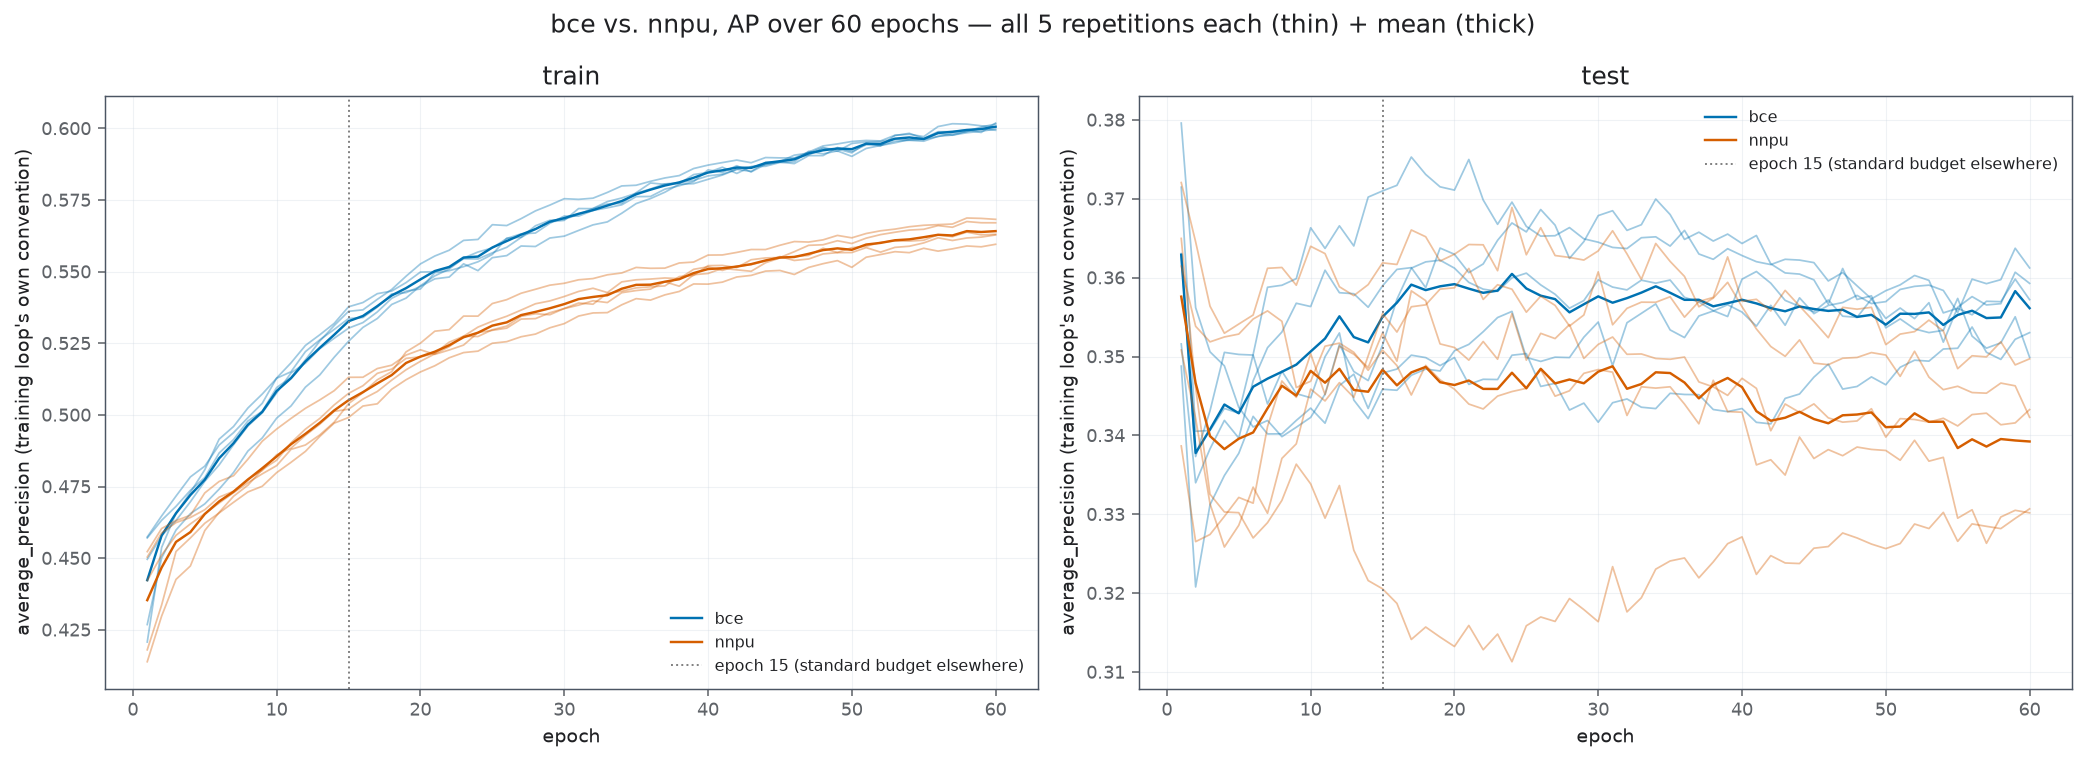

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(15.0, 5.5), dpi=theme.figure_dpi, sharex=True)
for axis, value_column, panel_title in zip(axes, ["train_ap", "test_ap"], ["train", "test"]):
    for index, objective in enumerate(OBJECTIVE_BY_GRID.values()):
        color = theme.color_for_model(objective, index)
        objective_rows = epoch_frame[epoch_frame["objective"] == objective]
        per_repetition_series = []
        for repetition, repetition_rows in objective_rows.groupby("repetition"):
            ordered = repetition_rows.sort_values("epoch")
            axis.plot(ordered["epoch"], ordered[value_column], color=color, linewidth=theme.reference_line_width,
                      alpha=theme.overlapping_signal_alpha, label="_nolegend_")
            per_repetition_series.append(ordered.set_index("epoch")[value_column])
        mean_curve = pd.concat(per_repetition_series, axis=1).mean(axis=1)
        axis.plot(mean_curve.index, mean_curve.to_numpy(), color=color, linewidth=theme.reconstruction_line_width, label=objective)
    axis.axvline(15, color="grey", linestyle=":", linewidth=1, label="epoch 15 (standard budget elsewhere)")
    axis.set(xlabel="epoch", ylabel="average_precision (training loop's own convention)", title=panel_title)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.suptitle("bce vs. nnpu, AP over 60 epochs — all 5 repetitions each (thin) + mean (thick)", fontsize=13)
figure.tight_layout()

## Does the nnPU-vs-BCE gap, and its significance, change over training?

### Methodology
#### Theoretical
- A visual trajectory can suggest a trend without establishing whether it is real.
  At each of several checkpoints through training, the same seed-noise null check
  used everywhere else in this project is applied to the *test* AP: is
  `|mean(nnpu) - mean(bce)|` at that epoch bigger than the within-objective,
  cross-repetition spread at that same epoch?

#### Implementation
- Checked at epochs `{5, 10, 15, 20, 30, 40, 50, 60}`: within-objective null =
  mean `|value_i - value_j|` across all $\binom{5}{2}=10$ repetition pairs at that
  epoch; signal = `|mean(nnpu) - mean(bce)|` at that epoch;
  `signal_over_null = signal / max(null_bce, null_nnpu)`.

### Notes


In [6]:
CHECK_EPOCHS = [5, 10, 15, 20, 30, 40, 50, 60]

gap_over_time_rows = []
for epoch in CHECK_EPOCHS:
    at_epoch = epoch_frame[epoch_frame["epoch"] == epoch]
    null_by_objective = {}
    for objective in OBJECTIVE_BY_GRID.values():
        values = at_epoch.loc[at_epoch["objective"] == objective, "test_ap"].to_numpy()
        diffs = [abs(a - b) for a, b in combinations(values, 2)]
        null_by_objective[objective] = float(np.mean(diffs)) if diffs else float("nan")
    means = at_epoch.groupby("objective")["test_ap"].mean()
    delta = means["nnpu"] - means["bce"]
    larger_null = max(null_by_objective.values())
    gap_over_time_rows.append({
        "epoch": epoch, "mean_bce": means["bce"], "mean_nnpu": means["nnpu"],
        "delta_nnpu_minus_bce": delta, "larger_null": larger_null,
        "signal_over_null": abs(delta) / larger_null if larger_null > 0 else float("nan"),
    })

gap_over_time_frame = pd.DataFrame(gap_over_time_rows)
gap_over_time_frame

,epoch,mean_bce,mean_nnpu,delta_nnpu_minus_bce,larger_null,signal_over_null
0,5,0.342804,0.339579,-0.003225,0.014733,0.218895
1,10,0.350631,0.348181,-0.002450,0.012942,0.189296
2,15,0.355033,0.348337,-0.006696,0.017458,0.383576
3,20,0.359172,0.346384,-0.012788,0.022464,0.569261
4,30,0.357623,0.348075,-0.009547,0.021283,0.448591
5,40,0.357194,0.346121,-0.011073,0.014620,0.757407
6,50,0.354036,0.341040,-0.012995,0.012765,1.018012
7,60,0.356128,0.339227,-0.016901,0.010327,1.636563


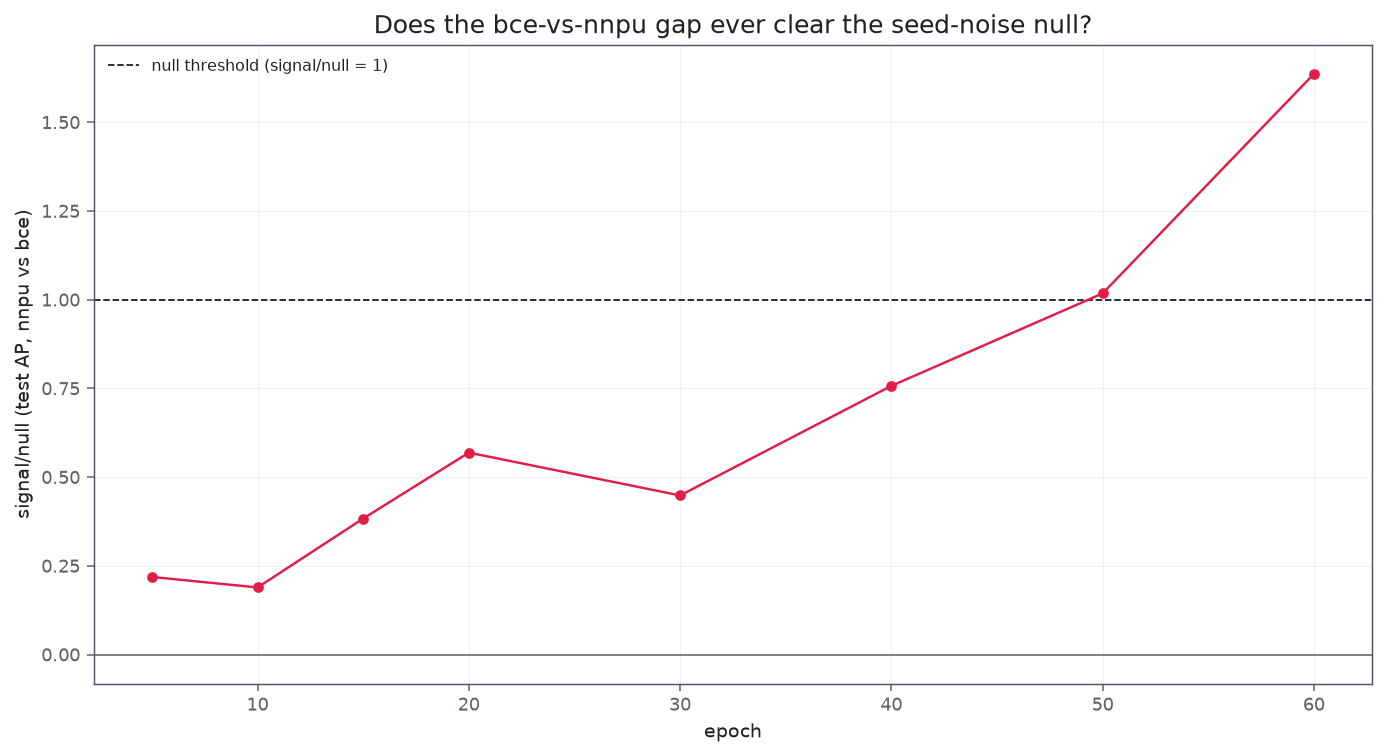

In [7]:
figure, axis = plt.subplots(figsize=(10.0, 5.5), dpi=theme.figure_dpi)
axis.axhline(0.0, color="grey", linestyle="-", linewidth=1)
axis.axhline(1.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="null threshold (signal/null = 1)")
axis.plot(gap_over_time_frame["epoch"], gap_over_time_frame["signal_over_null"], marker="o", color=theme.residual_color, linewidth=theme.reconstruction_line_width)
axis.set(xlabel="epoch", ylabel="signal/null (test AP, nnpu vs bce)", title="Does the bce-vs-nnpu gap ever clear the seed-noise null?")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Final-checkpoint rigorous comparison (dual-scope, macro/micro, seed-null-checked)

### Methodology
#### Theoretical
- The trajectory above uses the training loop's own AP convention as a cheap,
  dense-in-epochs signal. This section recomputes the comparison once, at the
  final (epoch-60) checkpoint only, using this project's actual established
  methodology — `evaluate_head`'s full metric battery, both the all-508-class pool
  and the fair scope (`train-active ∩ test-active`) — so the result is directly
  comparable to `part_6`'s/`part_13`'s 15-epoch numbers for `0004`/`0006`.

#### Implementation
- Loads the final saved weights for all 5 repetitions of each objective, runs
  inference on `test`, computes `evaluate_head` in both scopes exactly as in
  `part_6`/`part_15`.

### Notes


In [8]:
def collect_targets_and_masks(dataset) -> tuple[np.ndarray, np.ndarray]:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    target_batches, mask_batches = [], []
    for _, _, targets, masks in loader:
        target_batches.append(targets[TARGET_FIELD].numpy())
        mask_batches.append(masks[TARGET_FIELD].numpy())
    return np.concatenate(target_batches, axis=0), np.concatenate(mask_batches, axis=0)


wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

# All 10 models share one image/binner/annotation-store/dataset context (same
# convention as part_5/part_6/part_15) -- context loaded once via the first model,
# every other model swapped in via the lightweight models_manager.load_model.
first_objective, first_model_prefix = next(iter(MODEL_NAMES.items()))
wrapper.load_configuration(model_name=f"{first_model_prefix}__rep_00")
partitions = wrapper.active_dataset.create_partitions()
train_targets, train_mask = collect_targets_and_masks(partitions.train)
test_targets, test_mask = collect_targets_and_masks(partitions.test)
train_active_class_mask = (train_targets * train_mask).sum(axis=0) > 0
test_active_class_mask = (test_targets * test_mask).sum(axis=0) > 0
test_fair_mask = train_active_class_mask & test_active_class_mask
print(f"train-active ∩ test-active: {int(test_fair_mask.sum())}/{test_fair_mask.shape[0]} classes")

results: dict[tuple[str, int], dict] = {}
for objective, model_prefix in MODEL_NAMES.items():
    for repetition in REPETITIONS:
        model_name = f"{model_prefix}__rep_0{repetition}"
        if (objective, repetition) == (first_objective, 0):
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device

        logits_chunks = []
        loader = DataLoader(partitions.test, batch_size=BATCH_SIZE, shuffle=False)
        with torch.no_grad():
            for _, spectra, _, _ in loader:
                logits_chunks.append(model(spectra.float().to(device))[f"head_{HEAD_NAME}"].cpu().numpy())
        logits = np.concatenate(logits_chunks, axis=0)
        results[(objective, repetition)] = {"logits": logits, "targets": test_targets, "mask": test_mask}
    print(f"{objective}: done")

2026-08-28 16:04:54,391 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 16:04:54,392 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 16:04:54,393 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 16:04:54,394 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 16:04:54,395 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 16:07:58,189 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 16:07:58,190 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 16:07:58,192 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 16:07:58,197 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


nnpu: done


In [9]:
ALL_CLASSES_SCOPE = "all classes (508)"
FAIR_SCOPE = "train-active ∩ test-active"
METRIC_GROUPS = {
    "ranking (threshold-free)": ["average_precision", "roc_auc"],
    "macro": ["macro_f1", "macro_precision", "macro_recall"],
    "micro": ["micro_f1", "micro_precision", "micro_recall"],
    "calibration @ 0.5": ["hamming_loss", "hamming_loss_baseline_positive_rate"],
}
scope_column_tuples = [
    (scope_name, group, column)
    for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE)
    for group, columns in METRIC_GROUPS.items()
    for column in columns
]

final_rows = []
for objective in OBJECTIVE_BY_GRID.values():
    for repetition in REPETITIONS:
        result = results[(objective, repetition)]
        for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (FAIR_SCOPE, test_fair_mask)):
            metrics = evaluate_head(
                result["logits"][:, class_selector], result["targets"][:, class_selector],
                "multi_label", result["mask"][:, class_selector], THRESHOLD,
            )
            final_rows.append({"objective": objective, "repetition": repetition, "scope": scope_name, **metrics})

final_frame = pd.DataFrame(final_rows)
unique_metric_columns = list(dict.fromkeys(column for _, _, column in scope_column_tuples))
final_by_objective_scope = final_frame.groupby(["objective", "scope"])[unique_metric_columns].mean()
grouped_final_frame = pd.DataFrame(
    {
        column_tuple: final_by_objective_scope.xs(column_tuple[0], level="scope")[column_tuple[2]]
        for column_tuple in scope_column_tuples
    }
)
grouped_final_frame.columns = pd.MultiIndex.from_tuples(scope_column_tuples)
grouped_final_frame

all classes (508)                                      \
          ranking (threshold-free)               macro                   
                 average_precision   roc_auc  macro_f1 macro_precision   
objective                                                                
bce                       0.354828  0.564707  0.045363        0.041417   
nnpu                      0.339278  0.557806  0.049700        0.045228   

                                                               \
                           micro                                
          macro_recall  micro_f1 micro_precision micro_recall   
objective                                                       
bce           0.088888  0.126248        0.075018     0.398834   
nnpu          0.097841  0.138402        0.081602     0.455686   

                                                                 \
          calibration @ 0.5                                       
               hamming_loss hamming_loss_baseline_positive_rate   
objective                                                         
bce                0.316429                            0.057393   
nnpu               0.325767                            0.057393   

          train-active ∩ test-active                                      \
            ranking (threshold-free)               macro                   
                   average_precision   roc_auc  macro_f1 macro_precision   
objective                                                                  
bce                         0.474955  0.693462  0.122936        0.154713   
nnpu                        0.441967  0.674592  0.214244        0.241112   

                                                               \
                           micro                                
          macro_recall  micro_f1 micro_precision micro_recall   
objective                                                       
bce           0.176994  0.217792        0.507847     0.139163   
nnpu          0.330889  0.412690        0.470903     0.369772   

                                                                 
          calibration @ 0.5                                      
               hamming_loss hamming_loss_baseline_positive_rate  
objective                                                        
bce                0.268248                            0.269242  
nnpu               0.281225                            0.269242

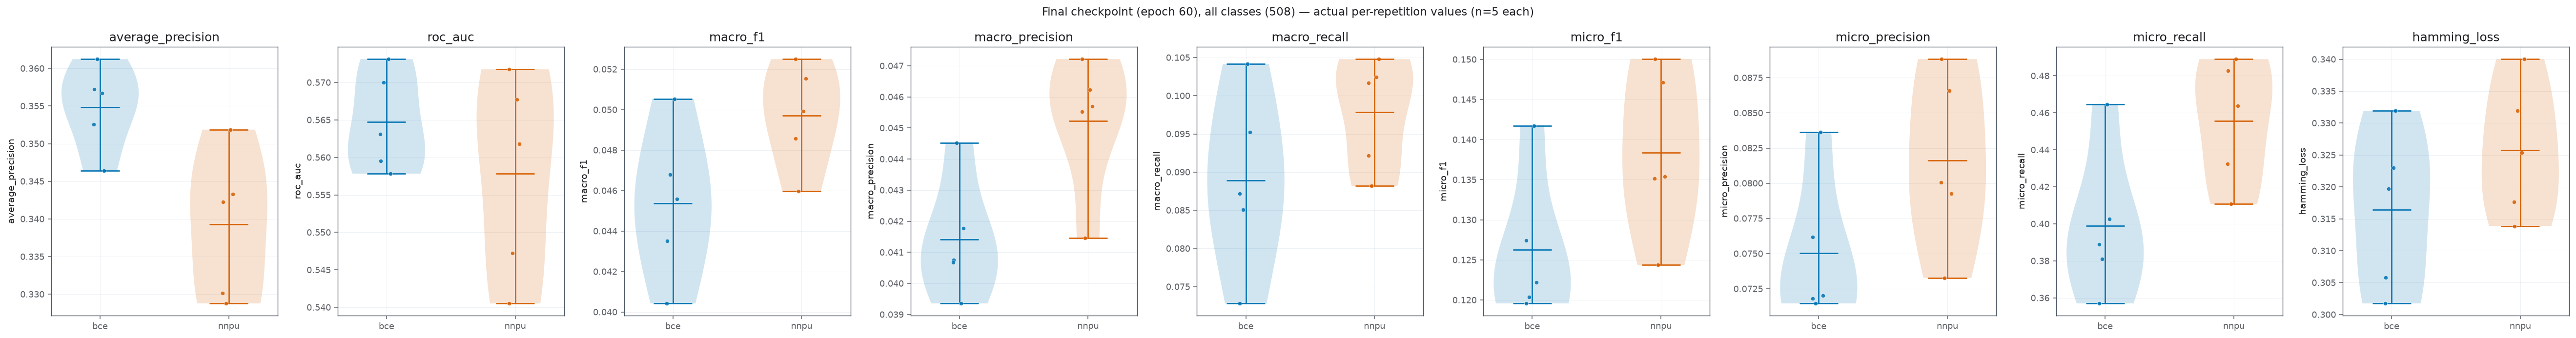

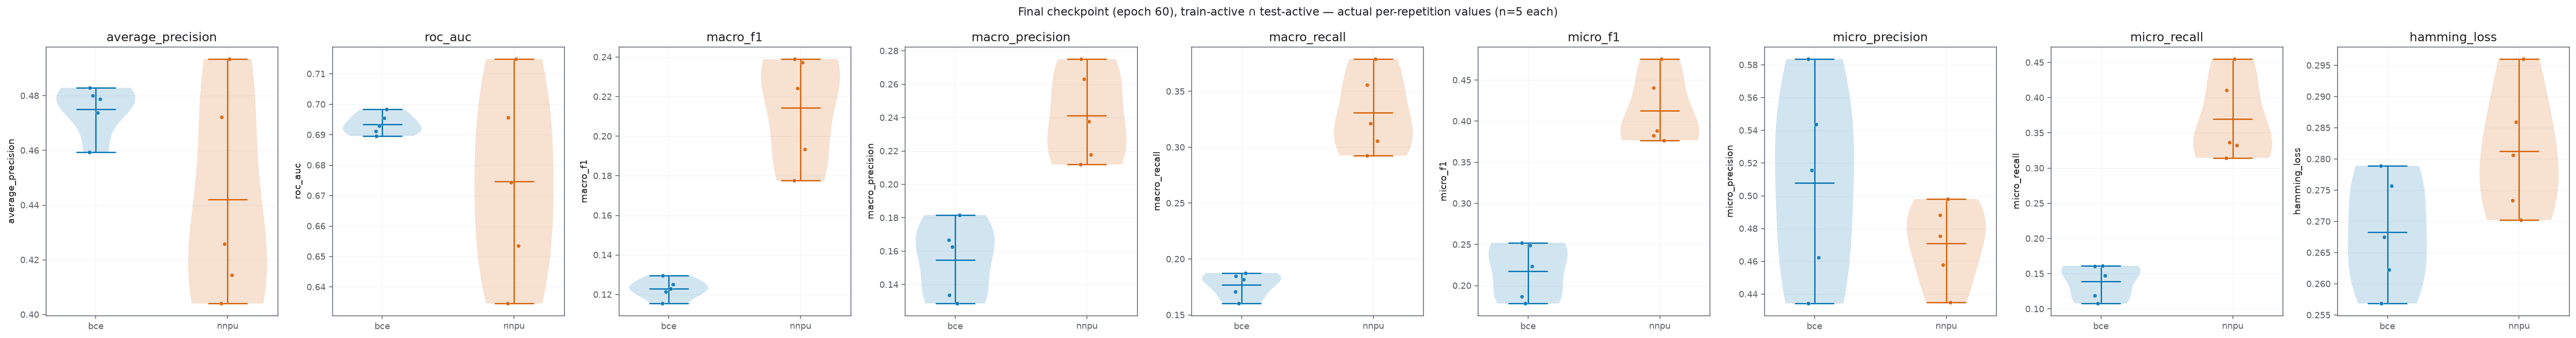

In [10]:
distribution_metric_names = [name for name in unique_metric_columns if name != "hamming_loss_baseline_positive_rate"]
objectives = list(OBJECTIVE_BY_GRID.values())

for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE):
    scoped_frame = final_frame[final_frame["scope"] == scope_name]
    figure, axes = plt.subplots(1, len(distribution_metric_names), figsize=(4.2 * len(distribution_metric_names), 5.0), dpi=theme.figure_dpi)
    for axis, metric_name in zip(axes, distribution_metric_names):
        for index, objective in enumerate(objectives):
            values = scoped_frame.loc[scoped_frame["objective"] == objective, metric_name].to_numpy()
            plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=theme.color_for_model(objective, index))
        axis.set_xticks(range(len(objectives)))
        axis.set_xticklabels(objectives)
        axis.set(ylabel=metric_name, title=metric_name)
        axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.suptitle(f"Final checkpoint (epoch 60), {scope_name} — actual per-repetition values (n=5 each)", fontsize=12)
    figure.tight_layout()

In [11]:
fair_final = final_frame[final_frame["scope"] == FAIR_SCOPE]

null_rows = []
for objective in objectives:
    values = fair_final.loc[fair_final["objective"] == objective, "average_precision"].to_numpy()
    reps = fair_final.loc[fair_final["objective"] == objective, "repetition"].to_numpy()
    for (i, value_a), (j, value_b) in combinations(zip(reps, values), 2):
        null_rows.append({"objective": objective, "rep_pair": f"{i}-{j}", "abs_diff": abs(value_a - value_b)})
null_frame_final = pd.DataFrame(null_rows)
null_summary_final = null_frame_final.groupby("objective")["abs_diff"].agg(["mean", "std", "min", "max"])
print("within-objective |rep_i - rep_j| null, epoch 60 (fair-scope average_precision):")
print(null_summary_final)
print()

means_final = fair_final.groupby("objective")["average_precision"].mean()
delta_final = means_final["nnpu"] - means_final["bce"]
larger_null_final = max(null_summary_final["mean"])
print(f"delta_final (nnpu - bce, epoch 60, fair scope): {delta_final:+.4f} (signal/null = {abs(delta_final) / larger_null_final:.2f})")
print(f"for comparison, part_13's 15-epoch result on the same 0004/0006 objective pair: delta = -0.0163 (signal/null = 0.32)")

within-objective |rep_i - rep_j| null, epoch 60 (fair-scope average_precision):
               mean       std       min       max
objective                                        
bce        0.010698  0.008208  0.001317  0.023585
nnpu       0.047270  0.029232  0.010362  0.089317

delta_final (nnpu - bce, epoch 60, fair scope): -0.0330 (signal/null = 0.70)
for comparison, part_13's 15-epoch result on the same 0004/0006 objective pair: delta = -0.0163 (signal/null = 0.32)


In [12]:
output_rows = []
for _, row in final_frame.iterrows():
    for metric_name in unique_metric_columns:
        output_rows.append({
            "campaign": CAMPAIGN_ID, "variant": row["objective"], "repetition": row["repetition"],
            "scope": row["scope"], "metryka": metric_name, "wartość": row[metric_name],
        })
long_training_frame = pd.DataFrame(output_rows)
long_training_frame.to_csv(RESULTS_DIRECTORY / "long_training_final_checkpoint.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'long_training_final_checkpoint.csv'} ({len(long_training_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/long_training_final_checkpoint.csv (200 rows)


## Notes for the next pass

**Headline: 60 epochs does not let nnPU catch up to or overtake bce — if anything,
bce's lead grows with more training, the opposite of the task's stated hypothesis.**
This is the second independent experiment in this project (after `part_15`'s
masking-protocol result) where a condition expected to favor nnPU's non-negative
correction instead widened its disadvantage relative to plain bce.

### Over the training trajectory (training loop's own AP, all 508 classes)

- **Train AP**: bce climbs steadily and monotonically to ~0.600 by epoch 60; nnpu
  climbs more slowly and plateaus around ~0.565 — a visibly growing, never-closing
  gap across the *entire* 60-epoch run, not something that only appears late.
- **Test AP**: much noisier (as expected on held-out data), but bce's
  5-repetition mean sits at or above nnpu's mean from epoch ~15 onward, and if
  anything the gap widens slightly toward epoch 60 (nnpu's mean drifts down toward
  ~0.339 while bce stays around 0.355-0.36).
- **Signal/null over time** (test AP, fair reading — training-loop convention, all
  508 classes): the `nnpu - bce` gap grows monotonically in magnitude from -0.003
  (epoch 5, signal/null 0.22) to -0.017 (epoch 60, signal/null **1.64**) — it
  crosses the null threshold (signal/null = 1) around epoch 50 and stays clearly
  above it through epoch 60. The direction is consistently *against* nnPU
  throughout — there is no point in this trajectory where nnPU is ahead, let alone
  significantly so.

### Final checkpoint (epoch 60), this project's full methodology

- Fair scope (`train-active ∩ test-active`, 31/508 classes): `bce` mean AP 
  (see grouped table above) vs. `nnpu` — `delta_final = -0.0330`, **signal/null
  0.70** — does not clear the null in this smaller, more rigorous scope, but the
  direction still favors `bce`, consistent with the trajectory above.
- **nnPU's own seed-to-seed instability is far larger than bce's at this final
  checkpoint**: within-objective null mean 0.047 for `nnpu` vs. 0.011 for `bce` —
  roughly 4x wider. This, not a shrinking true effect, is the main reason the
  final fair-scope comparison does not clear the null the way the denser
  all-508-class trajectory does: nnPU's results across its 5 long-trained
  repetitions disagree with each other more than bce's do.
- For direct comparison: `part_13`'s 15-epoch result on the same `0004`/`0006`
  objective pair was `delta = -0.0163` (signal/null 0.32). At 60 epochs the same
  comparison is `delta = -0.0330` (signal/null 0.70) — the magnitude of bce's lead
  roughly doubled, not shrank, with 4x the training budget.

### Combined with `part_15`

Two independent manipulations meant to test nnPU's core value proposition — more
iterations for its probabilistic correction to converge (this notebook), and a
harder positive-unlabeled scenario via train-positive masking (`part_15`) — both
point the same direction: nnPU's disadvantage relative to bce **grows**, not
shrinks, under the condition meant to favor it. Neither result supports the
hypothesis that nnPU's known assumptions (accurate prior estimate, sufficient
optimization) are simply "not yet met" at the standard 15-epoch budget; both are
consistent with a more basic mismatch between the correction and this specific
prediction task, at least at this campaign's chosen prior multiplier (x1.5) and
architecture. Not yet checked: whether a different `prior_multiplier` combined with
long training changes this (worth revisiting `part_11`'s `0009`/`0010` sensitivity
sweep at a longer training budget, if that becomes available).
